In [ ]:
!pip install kaggle

In [ ]:
#!/usr/bin/env python
# coding: utf-8
# -*- coding: utf-8 -*-

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import random
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Activation
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

import csv

warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from google.colab import userdata

# Criar o diretório .kaggle se não existir
!mkdir -p ~/.kaggle

# Tentar usar segredos do Colab para as credenciais
try:
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        f.write(f'{{"username":"{os.environ["KAGGLE_USERNAME"]}","key":"{os.environ["KAGGLE_KEY"]}"}}')
    os.chmod('/root/.kaggle/kaggle.json', 600)
    print("Credenciais do Kaggle carregadas dos segredos do Colab.")
except Exception:
    print("Erro ao carregar credenciais do Kaggle dos segredos. Tentando usar kaggle.json do ambiente de arquivos...")
    # Se não houver segredos, assumir que kaggle.json foi carregado manualmente
    if os.path.exists('kaggle.json'):
        !mv kaggle.json ~/.kaggle/
        !chmod 600 ~/.kaggle/kaggle.json
        print("kaggle.json movido para ~/.kaggle/.")
    else:
        print("Aviso: kaggle.json não encontrado. Por favor, faça o upload ou configure os segredos do Colab.")

# Baixar o dataset
# O ID do dataset é 'fidelissauro/combustiveis-brasil'
!kaggle datasets download -d fidelissauro/combustiveis-brasil

# Descompactar o arquivo
!unzip combustiveis-brasil.zip

print("Dataset 'combustiveis-brasil.csv' baixado e descompactado.")

Credenciais do Kaggle carregadas dos segredos do Colab.
Dataset URL: https://www.kaggle.com/datasets/fidelissauro/combustiveis-brasil
License(s): Community Data License Agreement - Permissive - Version 1.0
100% 284k/284k [00:00<00:00, 96.6MB/s]

Archive:  combustiveis-brasil.zip
  inflating: combustiveis-brasil.csv  
  inflating: combustiveis-estados.csv  
  inflating: combustiveis-regioes.csv  
Dataset 'combustiveis-brasil.csv' baixado e descompactado.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Carregar o dataset combustiveis-brasil.csv
# Usar encoding='latin1' pois datasets brasileiros frequentemente usam essa codificação
df = pd.read_csv('combustiveis-brasil.csv', encoding='latin1')
# data = df.copy()
# # Exibir as primeiras 5 linhas do DataFrame para inspeção inicial
# print("Primeiras 5 linhas do dataset 'combustiveis-brasil.csv':")
# display(df.head())

# # Exibir informações sobre o DataFrame (tipos de dados, valores não nulos)
# print("\nInformações sobre o dataset:")
# display(df.info())

# # Exibir estatísticas descritivas básicas
# print("\nEstatísticas descritivas do dataset:")
# display(df.describe())

In [ ]:

# data = data.to_numpy()[1:-1,:]
# data
df

,referencia,ano,mes,gasolina_comum_preco_revenda_avg,gasolina_comum_preco_revenda_min,gasolina_comum_preco_revenda_max,gasolina_aditivada_preco_revenda_avg,gasolina_aditivada_preco_revenda_min,gasolina_aditivada_preco_revenda_max,etanol_hidratado_preco_revenda_avg,...,oleo_diesel_preco_revenda_max,oleo_diesel_s10_preco_revenda_avg,oleo_diesel_s10_preco_revenda_min,oleo_diesel_s10_preco_revenda_max,gas_cozinha_glp_preco_revenda_avg,gas_cozinha_glp_preco_revenda_min,gas_cozinha_glp_preco_revenda_max,gas_natural_veicular_gnv_preco_revenda_avg,gas_natural_veicular_gnv_preco_revenda_min,gas_natural_veicular_gnv_preco_revenda_max
0,2001-07,2001,7,1.6814,1.379,2.00,NaN,NaN,NaN,1.0093,...,1.00,NaN,NaN,NaN,17.1949,12.00,24.5,0.7300,0.509,0.799
1,2001-08,2001,8,1.7110,1.440,2.38,NaN,NaN,NaN,1.0143,...,1.28,NaN,NaN,NaN,17.7025,12.50,27.0,0.7409,0.699,0.799
2,2001-09,2001,9,1.7180,1.430,2.38,NaN,NaN,NaN,1.0265,...,1.28,NaN,NaN,NaN,17.8996,12.50,29.0,0.7405,0.699,0.799
3,2001-10,2001,10,1.7787,1.410,2.48,NaN,NaN,NaN,1.0391,...,1.39,NaN,NaN,NaN,18.7322,12.00,30.5,0.7653,0.699,0.899
4,2001-11,2001,11,1.7802,1.440,2.45,NaN,NaN,NaN,1.0326,...,1.32,NaN,NaN,NaN,18.8690,12.00,31.0,0.7795,0.699,0.899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,2022-09,2022,9,5.0000,4.150,7.09,5.15,4.29,8.82,3.4800,...,8.89,6.94,5.49,8.89,112.3600,81.99,160.0,4.9900,3.180,7.430
254,2022-10,2022,10,4.8900,3.490,7.34,5.06,4.09,8.15,3.5600,...,8.52,6.68,3.59,8.49,109.7500,68.00,149.0,4.9000,3.190,6.890
255,2022-11,2022,11,5.0400,4.090,7.54,5.20,4.29,8.88,3.8300,...,8.52,6.69,5.75,8.59,110.1700,79.99,150.0,4.8000,3.190,6.790
256,2022-12,2022,12,4.9700,4.090,7.69,5.15,4.16,7.99,3.8400,...,8.52,6.49,5.57,9.65,109.1800,80.00,150.0,4.7700,3.190,6.740


In [ ]:
def discretizacao(data):
  #ano, mes, gosolina, preco_medio

  tamanho_x = data.shape[0] - 1

  dataset = []
  for i in range(tamanho_x - 1):
    d = data[i,0]
    d = d.split('-')

    ano = d[0]
    mes = d[1]

    v = []
    v.append(ano)
    v.append(mes)
    v.append(data[i,1])

    v.append(data[i + 1,1])
    dataset.append(v)

  return pd.DataFrame(dataset, columns=[["ano", "mes", "gasolina", "preco_medio"]])

In [ ]:
df_combustivel_discretizado = discretizacao(df[['referencia', 'gasolina_comum_preco_revenda_avg']].values)
df_combustivel_discretizado

,ano,mes,gasolina,preco_medio
0,2001,07,1.6814,1.7110
1,2001,08,1.7110,1.7180
2,2001,09,1.7180,1.7787
3,2001,10,1.7787,1.7802
4,2001,11,1.7802,1.7747
...,...,...,...,...
251,2022,07,6.0500,5.3900
252,2022,08,5.3900,5.0000
253,2022,09,5.0000,4.8900
254,2022,10,4.8900,5.0400


In [ ]:
df_combustivel_discretizado["ano"] = df_combustivel_discretizado["ano"].astype('int')
df_combustivel_discretizado["mes"] = df_combustivel_discretizado["mes"].astype('int')
df_combustivel_discretizado["gasolina"] = df_combustivel_discretizado["gasolina"].astype('float')
df_combustivel_discretizado["preco_medio"] = df_combustivel_discretizado["preco_medio"].astype('float')

print(df_combustivel_discretizado.dtypes)

X, y = df_combustivel_discretizado.iloc[:, :3], df_combustivel_discretizado.iloc[:, 3]

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.9, random_state=0, shuffle=False)

scaler = MinMaxScaler(feature_range=(0, 1))
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, shuffle=False)

ano              int64
mes              int64
gasolina       float64
preco_medio    float64
dtype: object


In [ ]:

model = Sequential()

model.add(Dense(36, input_shape=(3,), activation='relu'))
model.add(Dense(18, activation="relu"))
model.add(Dense(8, activation="relu"))
model.add(Dense(1, activation='linear'))
model.compile(loss='mse', optimizer='adam', metrics=['mean_absolute_error', 'mse'])

batch_size = 2
epochs = 200

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_val, y_val))

Epoch 1/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 2.1793 - mean_absolute_error: 1.2266 - mse: 2.1793 - val_loss: 0.2358 - val_mean_absolute_error: 0.3802 - val_mse: 0.2358
Epoch 2/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1175 - mean_absolute_error: 0.2854 - mse: 0.1175 - val_loss: 0.1776 - val_mean_absolute_error: 0.3496 - val_mse: 0.1776
Epoch 3/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0510 - mean_absolute_error: 0.1815 - mse: 0.0510 - val_loss: 0.0642 - val_mean_absolute_error: 0.2065 - val_mse: 0.0642
Epoch 4/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0273 - mean_absolute_error: 0.1384 - mse: 0.0273 - val_loss: 0.1195 - val_mean_absolute_error: 0.3063 - val_mse: 0.1195
Epoch 5/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0190 - mean_absolute_error: 0.1160 - mse: 0.0190 - val_loss: 0.1287 - val_mean_absolute_error: 0.3198 - val_mse: 0.1287
Epoch 6/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0148 - mean_absolute_error: 0.1024

In [ ]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


In [ ]:
auxDT=[]
for a in y_test:
    a1=[]
    a1.append(float(a))
    auxDT.append(a1)

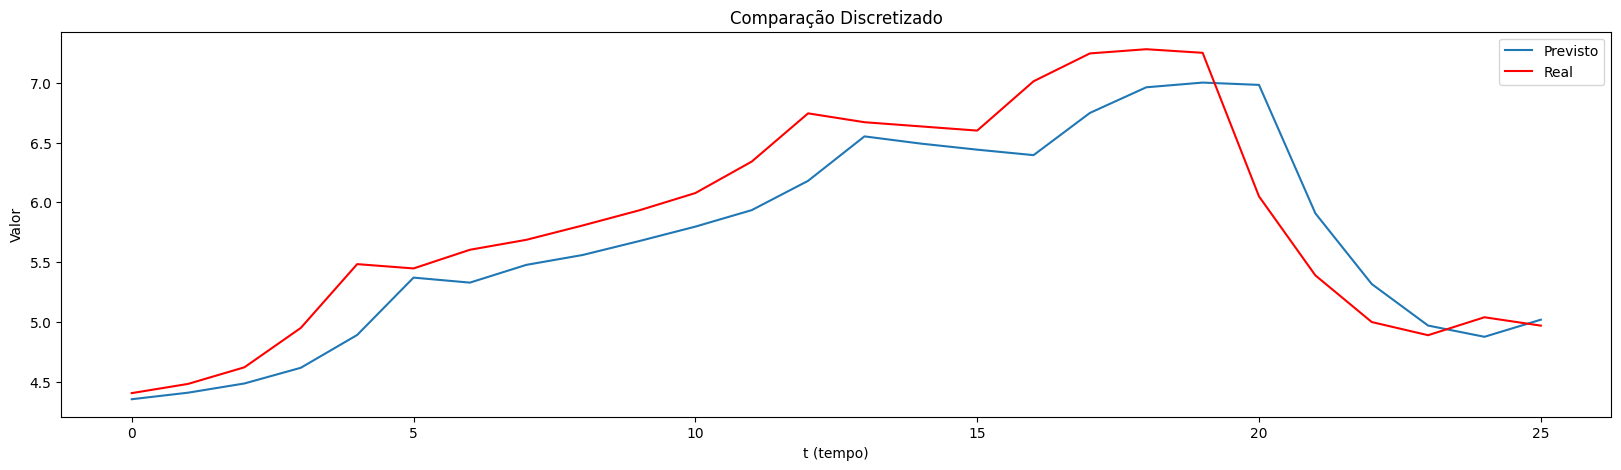

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(y_pred, label="Previsto") # Changed label to 'Previsto' as y_pred is the prediction
plt.plot(auxDT, color='red', label = 'Real') # Changed label to 'Real' as auxDT is from y_test
plt.title('Comparação Discretizado')
plt.legend()
plt.xlabel("t (tempo)")
plt.ylabel('Valor')
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

# Calculate evaluation metrics
mse = mean_squared_error(auxDT, y_pred)
mae = mean_absolute_error(auxDT, y_pred)
r2 = r2_score(auxDT, y_pred)
pearson_corr, _ = pearsonr(np.array(auxDT).flatten(), y_pred.flatten())

print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R-squared (R2 Score): {r2:.4f}')
print(f'Pearson Correlation Coefficient: {pearson_corr:.4f}')

Mean Squared Error (MSE): 0.1318
Mean Absolute Error (MAE): 0.2948
R-squared (R2 Score): 0.8306
Pearson Correlation Coefficient: 0.9269


In [ ]:
def discretizacao_trig(data):
  #sen(mes), sen(ano), co2, y

  tamanho_x = data.shape[0] - 1

  dataset = []
  for i in range(tamanho_x - 1):
    d = data[i,0]
    d = d.split('-')

    ano = d[0]
    mes = d[1]

    v = []
    v.append(np.sin(int(mes)))
    v.append(np.sin(int(ano)))
    v.append(data[i,1])
    v.append(data[i + 1,1])
    dataset.append(v)

  return pd.DataFrame(dataset, columns=['ano','mes','gasolina',"preco_medio"])

In [ ]:
# df

df_trig = discretizacao_trig(df[['referencia', 'gasolina_comum_preco_revenda_avg']].values)
df_trig

,ano,mes,gasolina,preco_medio
0,0.656987,0.193296,1.6814,1.7110
1,0.989358,0.193296,1.7110,1.7180
2,0.412118,0.193296,1.7180,1.7787
3,-0.544021,0.193296,1.7787,1.7802
4,-0.999990,0.193296,1.7802,1.7747
...,...,...,...,...
251,0.656987,-0.926751,6.0500,5.3900
252,0.989358,-0.926751,5.3900,5.0000
253,0.412118,-0.926751,5.0000,4.8900
254,-0.544021,-0.926751,4.8900,5.0400


In [ ]:
df_trig["ano"] = df_trig["ano"].astype('float')
df_trig["mes"] = df_trig["mes"].astype('float')
df_trig["gasolina"] = df_trig["gasolina"].astype('float')
df_trig["preco_medio"] = df_trig["preco_medio"].astype('float')

print(df_trig.dtypes)

X, y = df_trig.iloc[:, :3], df_trig.iloc[:, 3]

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.9, random_state=0, shuffle=False)

scaler = MinMaxScaler(feature_range=(0, 1))
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, shuffle=False)


ano            float64
mes            float64
gasolina       float64
preco_medio    float64
dtype: object


In [ ]:

model = Sequential()

model.add(Dense(36, input_shape=(3,), activation='relu'))
model.add(Dense(18, activation="relu"))
model.add(Dense(8, activation="relu"))
model.add(Dense(1, activation='linear'))
model.compile(loss='mse', optimizer='adam', metrics=['mean_absolute_error', 'mse'])

batch_size = 2
epochs = 200

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_val, y_val))

Epoch 1/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.4088 - mean_absolute_error: 1.2876 - mse: 2.4088 - val_loss: 1.6037 - val_mean_absolute_error: 1.1401 - val_mse: 1.6037
Epoch 2/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4353 - mean_absolute_error: 0.5299 - mse: 0.4353 - val_loss: 1.4248 - val_mean_absolute_error: 1.1366 - val_mse: 1.4248
Epoch 3/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1580 - mean_absolute_error: 0.2982 - mse: 0.1580 - val_loss: 0.4493 - val_mean_absolute_error: 0.6437 - val_mse: 0.4493
Epoch 4/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0217 - mean_absolute_error: 0.1045 - mse: 0.0217 - val_loss: 0.1385 - val_mean_absolute_error: 0.3441 - val_mse: 0.1385
Epoch 5/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0065 - mean_absolute_error: 0.0578 - mse: 0.0065 - val_loss: 0.0467 - val_mean_absolute_error: 0.1792 - val_mse: 0.0467
Epoch 6/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0048 - mean_absolute_error: 0.0507

In [ ]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


In [ ]:
auxDT=[]
for a in y_test:
    a1=[]
    a1.append(float(a))
    auxDT.append(a1)

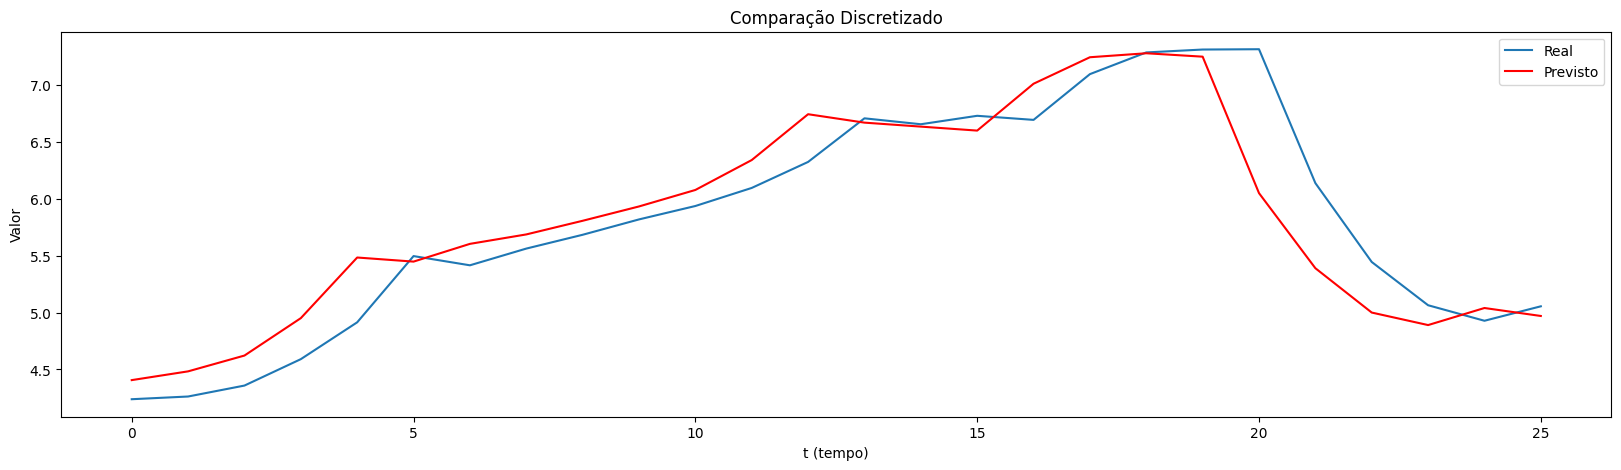

In [ ]:


plt.figure(figsize=(20, 5))
plt.plot(y_pred, label="Real")
plt.plot(auxDT, color='red', label = 'Previsto')
plt.title('Comparação Discretizado')
plt.legend()
plt.xlabel("t (tempo)")
plt.ylabel('Valor')
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

# Calculate evaluation metrics
mse = mean_squared_error(auxDT, y_pred)
mae = mean_absolute_error(auxDT, y_pred)
r2 = r2_score(auxDT, y_pred)
pearson_corr, _ = pearsonr(np.array(auxDT).flatten(), y_pred.flatten())

print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R-squared (R2 Score): {r2:.4f}')
print(f'Pearson Correlation Coefficient: {pearson_corr:.4f}')

Mean Squared Error (MSE): 0.1344
Mean Absolute Error (MAE): 0.2517
R-squared (R2 Score): 0.8272
Pearson Correlation Coefficient: 0.9233


Janela mento 2

In [ ]:
def discretizacao_trig(data,janela=1):
  #sen(mes), sen(ano), co2, y



  dataset = []
  for i in range(len(data) - janela):
    d = data[i,0]
    d = d.split('-')

    ano = int(d[0])
    mes = int(d[1])

    v = []
    v.append(np.sin(2 * np.pi * mes / 12))
    v.append(np.cos(2 * np.pi * mes / 12))

    for j in range(janela):

        v.append(data[i+j,1])

    v.append(data[i + janela,1])

    dataset.append(v)
  colunas = ['sen_mes', 'cos_mes']
  for j in range(janela):
        colunas.append(f'gasolina_t-{janela-j-1}')

  colunas.append('preco_medio')

  return pd.DataFrame(dataset, columns=colunas)

In [ ]:
janela=4
df_trig = discretizacao_trig(df[['referencia', 'gasolina_comum_preco_revenda_avg']].values,janela)
df_trig

,sen_mes,cos_mes,gasolina_t-3,gasolina_t-2,gasolina_t-1,gasolina_t-0,preco_medio
0,-5.000000e-01,-8.660254e-01,1.6814,1.7110,1.7180,1.7787,1.7802
1,-8.660254e-01,-5.000000e-01,1.7110,1.7180,1.7787,1.7802,1.7747
2,-1.000000e+00,-1.836970e-16,1.7180,1.7787,1.7802,1.7747,1.5875
3,-8.660254e-01,5.000000e-01,1.7787,1.7802,1.7747,1.5875,1.5088
4,-5.000000e-01,8.660254e-01,1.7802,1.7747,1.5875,1.5088,1.5739
...,...,...,...,...,...,...,...
249,5.000000e-01,-8.660254e-01,7.2800,7.2500,6.0500,5.3900,5.0000
250,1.224647e-16,-1.000000e+00,7.2500,6.0500,5.3900,5.0000,4.8900
251,-5.000000e-01,-8.660254e-01,6.0500,5.3900,5.0000,4.8900,5.0400
252,-8.660254e-01,-5.000000e-01,5.3900,5.0000,4.8900,5.0400,4.9700


In [ ]:
df_trig["sen_mes"] = df_trig["sen_mes"].astype('float')
df_trig["cos_mes"] = df_trig["cos_mes"].astype('float')
df_trig[f"gasolina_t-{(janela-1)}"] = df_trig[f"gasolina_t-{(janela-1)}"].astype('float')
df_trig["preco_medio"] = df_trig["preco_medio"].astype('float')

print(df_trig.dtypes)

X, y = df_trig.iloc[:, :3], df_trig.iloc[:, 3]

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.9, random_state=0, shuffle=False)

scaler = MinMaxScaler(feature_range=(0, 1))
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, shuffle=False)

sen_mes         float64
cos_mes         float64
gasolina_t-3    float64
gasolina_t-2    float64
gasolina_t-1    float64
gasolina_t-0    float64
preco_medio     float64
dtype: object


In [ ]:
model = Sequential()

model.add(Dense(36, input_shape=(3,), activation='relu'))
model.add(Dense(18, activation="relu"))
model.add(Dense(8, activation="relu"))
model.add(Dense(1, activation='linear'))
model.compile(loss='mse', optimizer='adam', metrics=['mean_absolute_error', 'mse'])

batch_size = 2
epochs = 200

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_val, y_val))

Epoch 1/200
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 2.8711 - mean_absolute_error: 1.4441 - mse: 2.8711 - val_loss: 2.1295 - val_mean_absolute_error: 1.3261 - val_mse: 2.1295
Epoch 2/200
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3807 - mean_absolute_error: 0.5115 - mse: 0.3807 - val_loss: 1.1329 - val_mean_absolute_error: 0.9545 - val_mse: 1.1329
Epoch 3/200
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1737 - mean_absolute_error: 0.3368 - mse: 0.1737 - val_loss: 0.5605 - val_mean_absolute_error: 0.6880 - val_mse: 0.5605
Epoch 4/200
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0551 - mean_absolute_error: 0.1794 - mse: 0.0551 - val_loss: 0.1527 - val_mean_absolute_error: 0.3513 - val_mse: 0.1527
Epoch 5/200
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0150 - mean_absolute_error: 0.0851 - mse: 0.0150 - val_loss: 0.0657 - val_mean_absolute_error: 0.2283 - val_mse: 0.0657
Epoch 6/200
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0074 - mean_absolute_error: 0.0593

In [ ]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


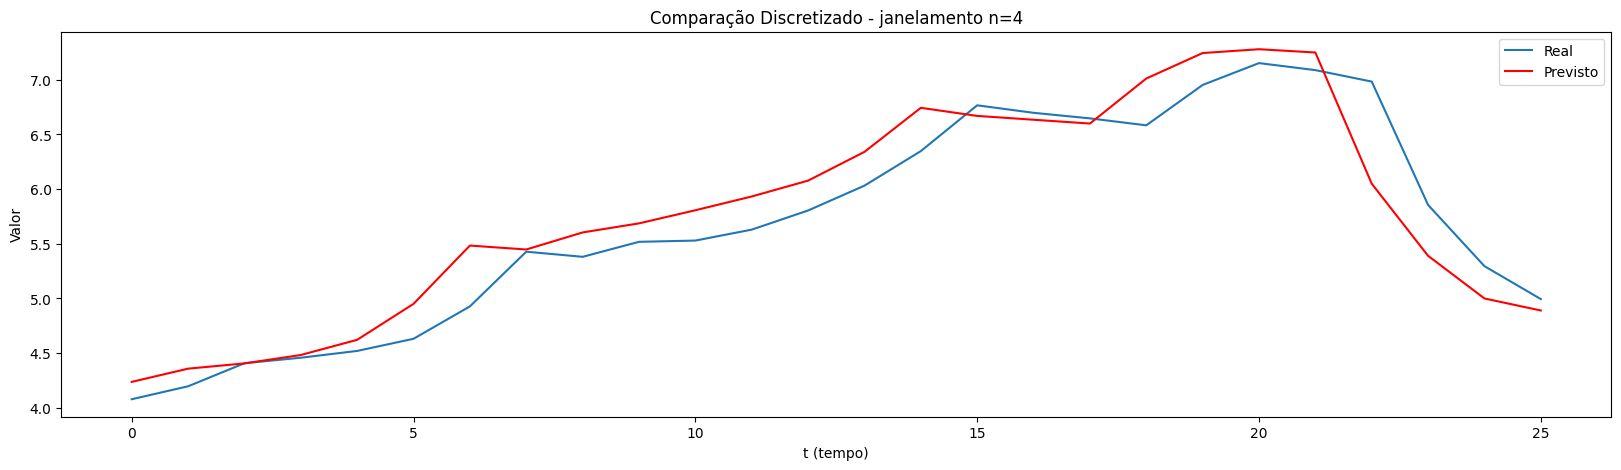

In [ ]:
auxDT=[]
for a in y_test:
    a1=[]
    a1.append(float(a))
    auxDT.append(a1)

plt.figure(figsize=(20, 5))
plt.plot(y_pred, label="Real")
plt.plot(auxDT, color='red', label = 'Previsto')
plt.title(f'Comparação Discretizado - janelamento n={janela}')
plt.legend()
plt.xlabel("t (tempo)")
plt.ylabel('Valor')
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

# Calculate evaluation metrics
mse = mean_squared_error(auxDT, y_pred)
mae = mean_absolute_error(auxDT, y_pred)
r2 = r2_score(auxDT, y_pred)
pearson_corr, _ = pearsonr(np.array(auxDT).flatten(), y_pred.flatten())

print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R-squared (R2 Score): {r2:.4f}')
print(f'Pearson Correlation Coefficient: {pearson_corr:.4f}')

Mean Squared Error (MSE): 0.0985
Mean Absolute Error (MAE): 0.2427
R-squared (R2 Score): 0.8909
Pearson Correlation Coefficient: 0.9501


In [ ]:
janela=2
df_trig = discretizacao_trig(df[['referencia', 'gasolina_comum_preco_revenda_avg']].values,janela)
# df_trig

df_trig["sen_mes"] = df_trig["sen_mes"].astype('float')
df_trig["cos_mes"] = df_trig["cos_mes"].astype('float')
df_trig[f"gasolina_t-{(janela-1)}"] = df_trig[f"gasolina_t-{(janela-1)}"].astype('float')
df_trig["preco_medio"] = df_trig["preco_medio"].astype('float')

print(df_trig.dtypes)

X, y = df_trig.iloc[:, :3], df_trig.iloc[:, 3]

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.9, random_state=0, shuffle=False)

scaler = MinMaxScaler(feature_range=(0, 1))
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, shuffle=False)

model = Sequential()

model.add(Dense(36, input_shape=(3,), activation='relu'))
model.add(Dense(18, activation="relu"))
model.add(Dense(8, activation="relu"))
model.add(Dense(1, activation='linear'))
model.compile(loss='mse', optimizer='adam', metrics=['mean_absolute_error', 'mse'])

batch_size = 2
epochs = 200

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_val, y_val))

y_pred = model.predict(x_test)

sen_mes         float64
cos_mes         float64
gasolina_t-1    float64
gasolina_t-0    float64
preco_medio     float64
dtype: object
Epoch 1/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 3.7267 - mean_absolute_error: 1.7659 - mse: 3.7267 - val_loss: 1.6867 - val_mean_absolute_error: 1.1842 - val_mse: 1.6867
Epoch 2/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2547 - mean_absolute_error: 0.4095 - mse: 0.2547 - val_loss: 0.5607 - val_mean_absolute_error: 0.6653 - val_mse: 0.5607
Epoch 3/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0698 - mean_absolute_error: 0.2035 - mse: 0.0698 - val_loss: 0.2177 - val_mean_absolute_error: 0.4283 - val_mse: 0.2177
Epoch 4/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0206 - mean_absolute_error: 0.0999 - mse: 0.0206 - val_loss: 0.0862 - val_mean_absolute_error: 0.2698 - val_mse: 0.0862
Epoch 5/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0091 - mean_absolute_error: 0.0609 - mse: 0.0091 - val_loss: 0.0391 - val_mean_a

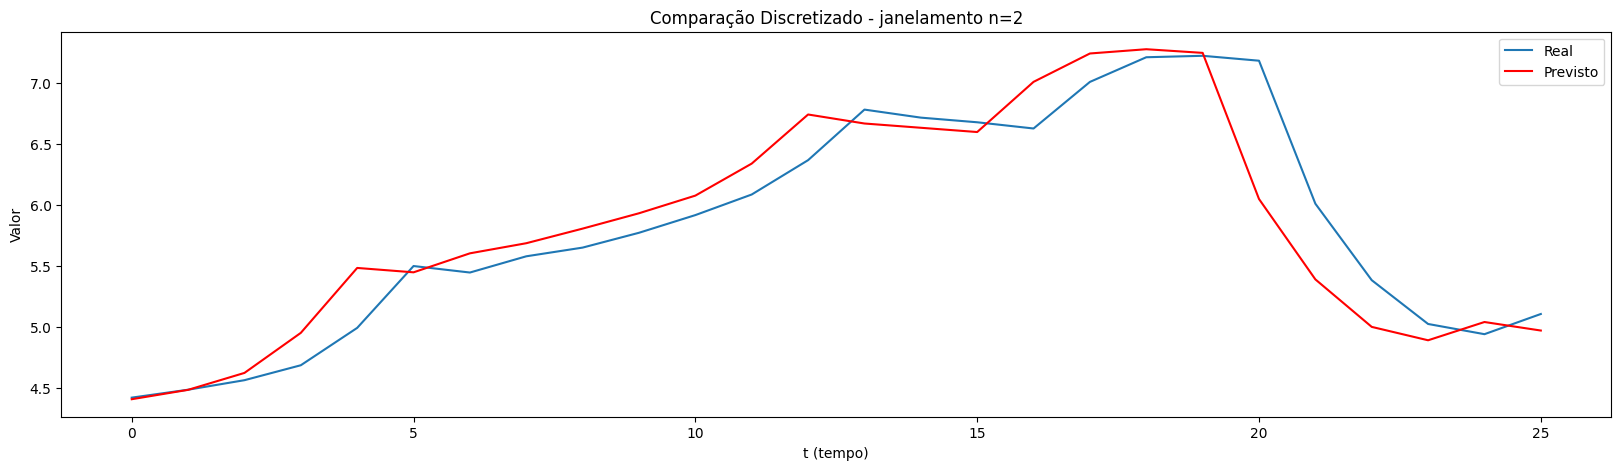

In [ ]:
auxDT=[]
for a in y_test:
    a1=[]
    a1.append(float(a))
    auxDT.append(a1)

plt.figure(figsize=(20, 5))
plt.plot(y_pred, label="Real")
plt.plot(auxDT, color='red', label = 'Previsto')
plt.title(f'Comparação Discretizado - janelamento n={janela}')
plt.legend()
plt.xlabel("t (tempo)")
plt.ylabel('Valor')
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

# Calculate evaluation metrics
mse = mean_squared_error(auxDT, y_pred)
mae = mean_absolute_error(auxDT, y_pred)
r2 = r2_score(auxDT, y_pred)
pearson_corr, _ = pearsonr(np.array(auxDT).flatten(), y_pred.flatten())

print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R-squared (R2 Score): {r2:.4f}')
print(f'Pearson Correlation Coefficient: {pearson_corr:.4f}')

Mean Squared Error (MSE): 0.1053
Mean Absolute Error (MAE): 0.2211
R-squared (R2 Score): 0.8646
Pearson Correlation Coefficient: 0.9328


In [ ]:
janela=10
df_trig = discretizacao_trig(df[['referencia', 'gasolina_comum_preco_revenda_avg']].values,janela)
# df_trig

df_trig["sen_mes"] = df_trig["sen_mes"].astype('float')
df_trig["cos_mes"] = df_trig["cos_mes"].astype('float')
df_trig[f"gasolina_t-{(janela-1)}"] = df_trig[f"gasolina_t-{(janela-1)}"].astype('float')
df_trig["preco_medio"] = df_trig["preco_medio"].astype('float')

print(df_trig.dtypes)

X, y = df_trig.iloc[:, :3], df_trig.iloc[:, 3]

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.9, random_state=0, shuffle=False)

scaler = MinMaxScaler(feature_range=(0, 1))
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, shuffle=False)

model = Sequential()

model.add(Dense(36, input_shape=(3,), activation='relu'))
model.add(Dense(18, activation="relu"))
model.add(Dense(8, activation="relu"))
model.add(Dense(1, activation='linear'))
model.compile(loss='mse', optimizer='adam', metrics=['mean_absolute_error', 'mse'])

batch_size = 2
epochs = 200

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_val, y_val))

y_pred = model.predict(x_test)

sen_mes         float64
cos_mes         float64
gasolina_t-9    float64
gasolina_t-8    float64
gasolina_t-7    float64
gasolina_t-6    float64
gasolina_t-5    float64
gasolina_t-4    float64
gasolina_t-3    float64
gasolina_t-2    float64
gasolina_t-1    float64
gasolina_t-0    float64
preco_medio     float64
dtype: object
Epoch 1/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.6162 - mean_absolute_error: 2.0648 - mse: 4.6162 - val_loss: 7.5058 - val_mean_absolute_error: 2.7045 - val_mse: 7.5058
Epoch 2/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6975 - mean_absolute_error: 0.6797 - mse: 0.6975 - val_loss: 2.1951 - val_mean_absolute_error: 1.3677 - val_mse: 2.1951
Epoch 3/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3331 - mean_absolute_error: 0.4846 - mse: 0.3331 - val_loss: 1.7004 - val_mean_absolute_error: 1.2082 - val_mse: 1.7004
Epoch 4/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2250 - mean_absolute_error: 0.3950 - mse: 0.2250 - val_loss: 1.1139 - 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


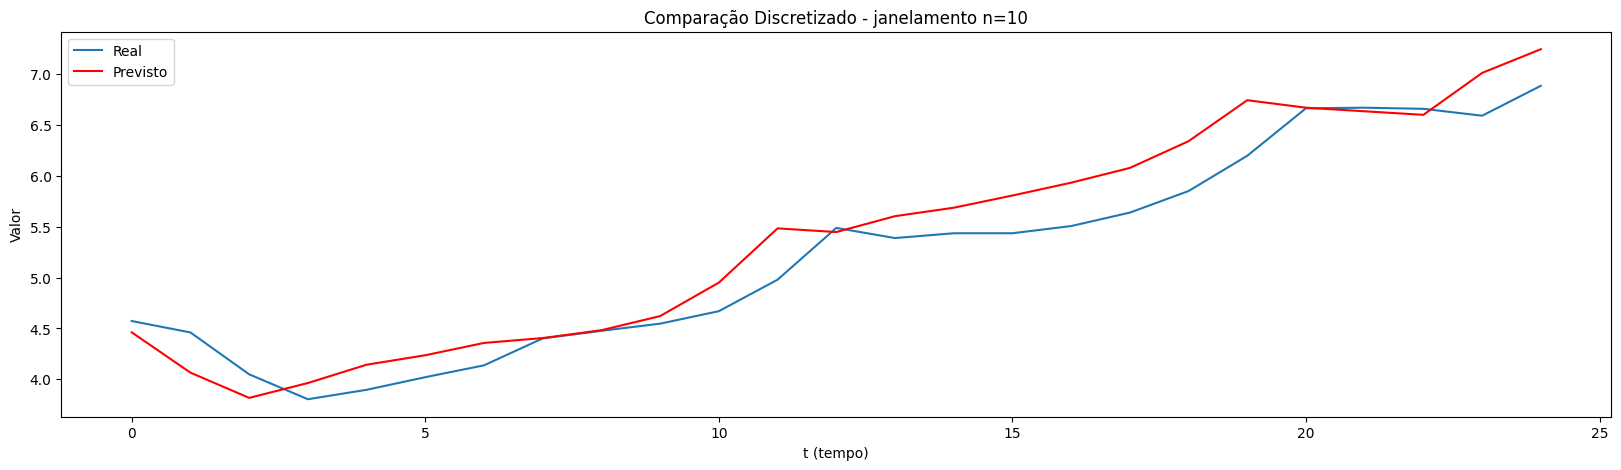

In [ ]:
auxDT=[]
for a in y_test:
    a1=[]
    a1.append(float(a))
    auxDT.append(a1)

plt.figure(figsize=(20, 5))
plt.plot(y_pred, label="Real")
plt.plot(auxDT, color='red', label = 'Previsto')
plt.title(f'Comparação Discretizado - janelamento n={janela}')
plt.legend()
plt.xlabel("t (tempo)")
plt.ylabel('Valor')
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

# Calculate evaluation metrics
mse = mean_squared_error(auxDT, y_pred)
mae = mean_absolute_error(auxDT, y_pred)
r2 = r2_score(auxDT, y_pred)
pearson_corr, _ = pearsonr(np.array(auxDT).flatten(), y_pred.flatten())

print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R-squared (R2 Score): {r2:.4f}')
print(f'Pearson Correlation Coefficient: {pearson_corr:.4f}')

Mean Squared Error (MSE): 0.0886
Mean Absolute Error (MAE): 0.2443
R-squared (R2 Score): 0.9214
Pearson Correlation Coefficient: 0.9759


In [ ]:
print("Training set percentage: 90%")
print("Testing set percentage: 10%")

A porcentagem de treino e teste é definida na função `train_test_split`. No código, você pode ver chamadas como:

```python
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.9, random_state=0, shuffle=False)
```

Neste exemplo, `train_size=0.9` indica que 90% dos dados são usados para o conjunto de treinamento e os restantes 10% são usados para o conjunto de teste. Em algumas partes do notebook, a parte de treino (`x_train`, `y_train`) é posteriormente dividida para um conjunto de validação, com `test_size=0.2` da parte de treino. Portanto, a validação utiliza 20% do conjunto de treinamento.